## Computing Spectral Coherence

When two brain regions communicate, their activity is coupled. This coupling can be revealed by calculating the association between signals recorded from these brain regions.

This notebook covers the following mathematical tools for investigating the association between two signals: spectral coherence, the Hilbert transform, and the phase locking value. Spectral coherence is a frequency-resolved analog of correlation built on the wavelet transform, the Hilbert transform enables you to extract a signal's instantaneous phase, and the phase locking value summarizes how consistently two signals hold a fixed phase relationship.

## Setup

### Import Libraries

Import the modules required for this session.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
import spectral
import sys
from pathlib import Path

### Utility Functions

Run the cell below to define utility functions used throughout this notebook.

In [3]:
class utils:
    @staticmethod
    def generate_coherent_signals(n_trials: int = 3,
                                  f_min: float = 5.0, 
                                  f_max: float = 100.0, 
                                  num_freqs: int = 50, 
                                  f_coherence: float = 40.0,
                                  f_coherence_width: float = 5.0,
                                  t_max: float = 3.0, 
                                  time_step: float = 0.0025,
                                  time_shift: float = 0.100,
                                  ):
        n_bins = int(np.ceil(t_max / time_step))
        time_vec = time_step * np.arange(n_bins)

        f = np.logspace(np.log10(f_min), np.log10(f_max), num_freqs)
        s1 = np.zeros((n_trials, n_bins))
        s2 = np.zeros((n_trials, n_bins))
        rng = np.random.default_rng(1)
        for j in range(n_trials):
            for i, f_i in enumerate(f):
                crosstalk = np.exp(-0.5 * ((f_i - f_coherence) / f_coherence_width)**2)
                a_i = 1.0 / f_i
                phi1 = 2 * np.pi * rng.random()
                phi2 = 2 * np.pi * rng.random()
                s1_i = a_i * np.sin(2 * np.pi * f_i * time_vec + phi1)
                s2_i = a_i * np.sin(2 * np.pi * f_i * time_vec + phi2)
                s1[j, :] += s1_i
                s2[j, :] += s2_i * (1 - crosstalk) + np.roll(s1_i, int(time_shift / time_step)) * crosstalk

        return time_vec, s1, s2

### Download Data

Run the cell below to download the datasets used in this notebook.

In [4]:
import owncloud

Path('../data').mkdir(exist_ok=True, parents=True)

oc = owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/NPyTrnkZPLWH9Yz', folder_password='ibots')
oc.get_file('/', '../data/spectral_dataset.mat')

True

## Computing Spectral Coherence

The spectral coherence at frequency $f$ and time delay $\tau$ is defined as:

$$C(f, \tau) = \frac{\left|\sum_{\ell} W_1^{(\ell)}(f, t) \cdot \overline{W_2^{(\ell)}(f, t-\tau)}\right|^2}{\sum_{\ell}|W_1^{(\ell)}(f,t)|^2 \cdot \sum_{\ell}|W_2^{(\ell)}(f,t)|^2}$$

where $W_i^{(\ell)}$ is the wavelet coefficient of signal $i$ in trial $\ell$ and the sums run over both trials and time points. Averaging complex cross-spectral products in the numerator before taking the absolute value is essential: if the phase difference between the two signals is consistent across trials, the trial sum adds coherently and the magnitude is large; if the phase difference is random, the trial sum cancels and coherence is near zero.

The time delay $\tau$ in the coherence function reveals not only whether two signals are coupled but also the time lag of the coupling. A peak at $\tau > 0$ indicates that signal 2 follows signal 1 with that latency, which is the expected pattern when one brain area drives another.

| Code | Description |
| --- | --- |
| `n_taus = int(2 * (time_shift / time_step))` | Number of lag bins on each side |
| `C, taus = spectral.coherence(W1, W2, tau_max=n_taus*time_step, ntau=n_taus, dt=time_step)` | Calculate coherence `C` between the spectra of signal 1 (`W1`) and 2 `W2` |
| `spectral.wavelet_dsignal_show(np.abs(C), taus, frequencies_wavelet)` | Plot coherence of signals with lag on x-axis and frequencies on y-axis |

---

We first generate two signals that are independently random but share a hidden coupling at one specific frequency band. Each signal is a superposition of sinusoids at logarithmically spaced frequencies with random trial-by-trial phases, mimicking the pink-noise background of neural signals. At one frequency, `f_coherence`, the second signal is replaced, in part, by a time-delayed copy of the first, creating a controlled coherence at that band.

Run the cell below to generate the two signals with `f_coherence = 40` and compute the wavelet spectra `W1` and `W2` for each of them. One trial of each signal is plotted.

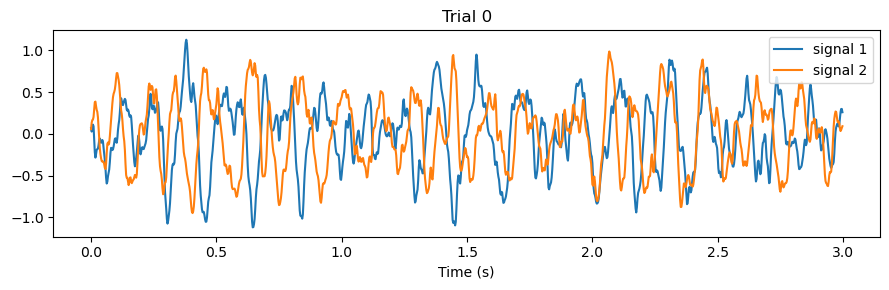

In [5]:
n_trials = 3
f_min = 5.0 
f_max = 100.0 
t_max = 3.0
time_step = 0.0025
# num_freqs = 50
time_shift = 0.100
f_coherence = 40.0
# f_coherence_width = 5.0

time_vec, signal1, signal2 = utils.generate_coherent_signals(n_trials, f_min, f_max, f_coherence=f_coherence, t_max = t_max, time_step = time_step, time_shift = time_shift)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_vec, signal1[0, :], label='signal 1')
ax.plot(time_vec, signal2[0, :], label='signal 2')
ax.set_xlabel('Time (s)'); ax.legend(); ax.set_title('Trial 0')
plt.tight_layout()

n_bands = 100; bandwidth = 1.5
W1, _, frequencies_wavelet, t_coi = spectral.wavelet_transform_morlet(signal1, n_bands=n_bands, freq_min=f_min, freq_max=f_max, dt=time_step, bandwidth=bandwidth)
W2, _, _, _ = spectral.wavelet_transform_morlet(signal2, n_bands=n_bands, freq_min=f_min, freq_max=f_max, dt=time_step, bandwidth=bandwidth)

**Example**: Compute and display the spectral coherence between `W1` and `W2` as a function of frequency and time lag. At which time lag and frequency is the coherence the highest?

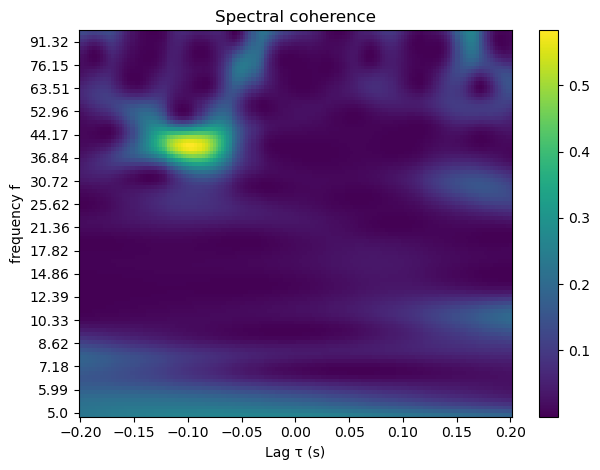

In [7]:
n_taus = int(2 * (time_shift / time_step))
C, taus = spectral.coherence(W1, W2, tau_max=n_taus * time_step, ntau=n_taus, dt=time_step)
spectral.wavelet_dsignal_show(np.abs(C), taus, frequencies_wavelet)
plt.title('Spectral coherence')
plt.xlabel('Lag τ (s)')
plt.tight_layout()

Run the cell below to generate two new signals with `f_coherence = 20` and compute the wavelet spectra `W1` and `W2` for each of them.

In [8]:
f_coherence = 20.0

time_vec, signal1, signal2 = utils.generate_coherent_signals(n_trials, f_min, f_max, f_coherence=f_coherence, t_max = t_max, time_step = time_step, time_shift = time_shift)
W1, _, frequencies_wavelet, t_coi = spectral.wavelet_transform_morlet(signal1, n_bands=n_bands, freq_min=f_min, freq_max=f_max, dt=time_step, bandwidth=bandwidth)
W2, _, _, _ = spectral.wavelet_transform_morlet(signal2, n_bands=n_bands, freq_min=f_min, freq_max=f_max, dt=time_step, bandwidth=bandwidth)


**Exercise**: Compute and display the spectral coherence between `W1` and `W2` as a function of frequency and time lag. At which time lag and frequency is the coherence the highest?

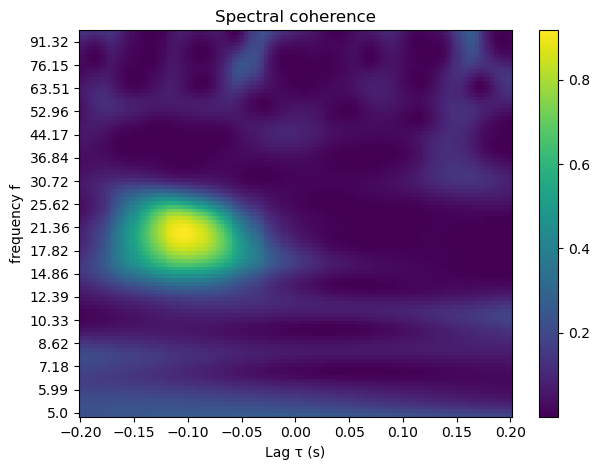

In [9]:
n_taus = int(2 * (time_shift / time_step))
C, taus = spectral.coherence(W1, W2, tau_max=n_taus * time_step, ntau=n_taus, dt=time_step)
spectral.wavelet_dsignal_show(np.abs(C), taus, frequencies_wavelet)
plt.title('Spectral coherence')
plt.xlabel('Lag τ (s)')
plt.tight_layout()

Run the cell below to generate two new signals with `f_coherence = 30` and `time_shift = 0.2` and compute the wavelet spectra `W1` and `W2` for each of them.

In [10]:
f_coherence = 30.0
time_shift = 0.2

time_vec, signal1, signal2 = utils.generate_coherent_signals(n_trials, f_min, f_max, f_coherence=f_coherence, t_max = t_max, time_step = time_step, time_shift = time_shift)
W1, _, frequencies_wavelet, t_coi = spectral.wavelet_transform_morlet(signal1, n_bands=n_bands, freq_min=f_min, freq_max=f_max, dt=time_step, bandwidth=bandwidth)
W2, _, _, _ = spectral.wavelet_transform_morlet(signal2, n_bands=n_bands, freq_min=f_min, freq_max=f_max, dt=time_step, bandwidth=bandwidth)


**Exercise**: Compute and display the spectral coherence between `W1` and `W2` as a function of frequency and time lag. At which time lag and frequency is the coherence the highest? Does signal 1 lead signal 2 or the other way around?

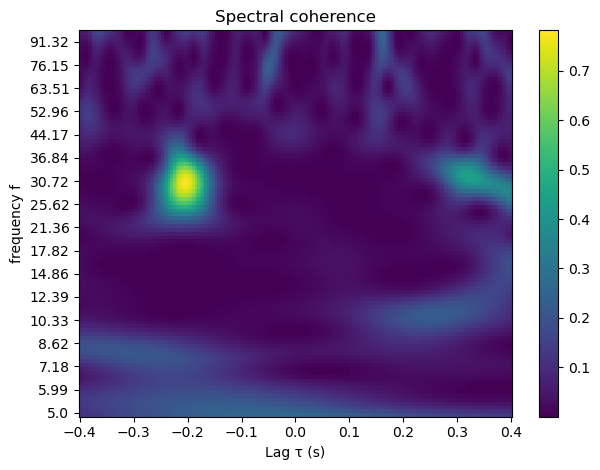

In [10]:
n_taus = int(2 * (time_shift / time_step))
C, taus = spectral.coherence(W1, W2, tau_max=n_taus * time_step, ntau=n_taus, dt=time_step)
spectral.wavelet_dsignal_show(np.abs(C), taus, frequencies_wavelet)
plt.title('Spectral coherence')
plt.xlabel('Lag τ (s)')
plt.tight_layout()

Run the cell below to load the synthetic V1 and V4 LFP data.

In [11]:
data = scipy.io.loadmat('../data/spectral_dataset.mat')
v1_lfp = data['V1_lfp']; v4_lfp = data['V4_lfp']

**Demo**: Compute the spectral coherence between V1 channel 22 and the V4 channel using `n_bands=15`, `freq_min=10`, `freq_max=100`. Do the same for V1 channel 77 and the single channel in V4. Display both results with the same scaling `plt.clim(0, 0.2)` in the same figure side-by-side.

Which V1 channel has the highest coherence with V4?

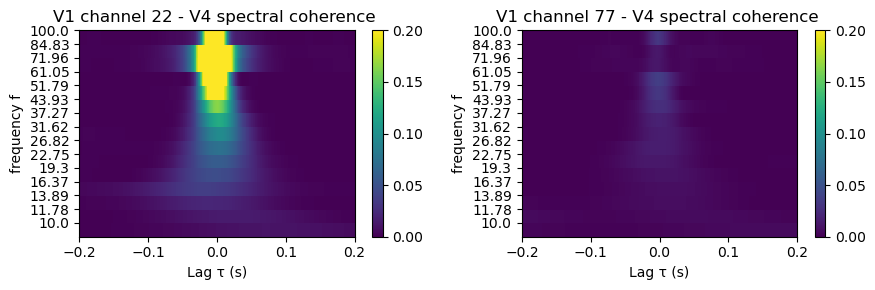

In [12]:
time_step_lfp = 1e-3
n_trials_r, n_time_r = v1_lfp.shape[:2]
time_lfp = time_step_lfp * np.arange(n_time_r)

W_v4, _, _, _ = spectral.wavelet_transform_morlet(
    v4_lfp.astype(float),
    n_bands=15, freq_min=10.0, freq_max=100.0, dt=time_step_lfp, bandwidth=1.5)

channel_of_interest = [22, 77]
plt.figure(figsize=(9, 3))
for i, channel in enumerate(channel_of_interest):
    W_v1, _, f_real, _ = spectral.wavelet_transform_morlet(
        v1_lfp[:, :, channel].astype(float),
        n_bands=15, freq_min=10.0, freq_max=100.0, dt=time_step_lfp, bandwidth=1.5)
    
    n_taus_r = int(2 * (0.1 / time_step_lfp))
    C_vv, taus_vv = spectral.coherence(W_v1, W_v4, tau_max=n_taus_r * time_step_lfp, ntau=n_taus_r, dt=time_step_lfp)
    plt.subplot(1, 2, 1 + i)
    spectral.wavelet_dsignal_show(np.abs(C_vv), taus_vv, f_real)
    plt.title(f'V1 channel {channel} - V4 spectral coherence '); plt.xlabel('Lag τ (s)')
    plt.clim(0, 0.2)
plt.tight_layout()

## The Hilbert Transform and Instantaneous Phase

A sinusoidal signal can be written as $s(t) = A \cos(2\pi f t + \phi)$. To extract the amplitude $A(t)$ and instantaneous phase $\phi(t)$ when both vary over time, we construct the analytic signal $z(t) = s(t) + i \hat{s}(t)$, where $\hat{s}(t)$ is the Hilbert transform of $s(t)$. The modulus $|z(t)| = A(t)$ is the instantaneous amplitude and $\arg z(t) = \phi(t)$ is the instantaneous phase.

Before applying the Hilbert transform, the signal must be bandpass-filtered to the frequency range of interest. Without filtering, the instantaneous phase is dominated by whatever frequency is most powerful and the estimate is meaningless for other frequency bands. A forward-backward (zero-phase) Butterworth filter preserves the phase of the signal and avoids introducing a systematic phase shift, which would contaminate phase-based measures.

The function `spectral.hilbert_bandpassed(signal, f_mid, f_width, dt)` applies a zero-phase 3rd-order Butterworth bandpass filter centered at `f_mid` with half-width `f_width`, then computes the Hilbert transform. It returns the complex analytic signal `z` and the filtered real signal.

| Code | Description |
| --- | --- |
| `z, s_filt = spectral.hilbert_bandpassed(signal, f_mid, f_width, dt)` | Analytic signal and bandpassed signal |
| `np.abs(z)` | Instantaneous amplitude |
| `np.angle(z)` | Instantaneous phase (radians, $-\pi$ to $\pi$) |
| `np.unwrap(np.angle(z))` | Unwrapped instantaneous phase |

---

Run the cell below to generate three 10 Hz signals. Each has an independently jittered phase process — but two of the three share a hidden phase relationship. A short segment of each signal is plotted.

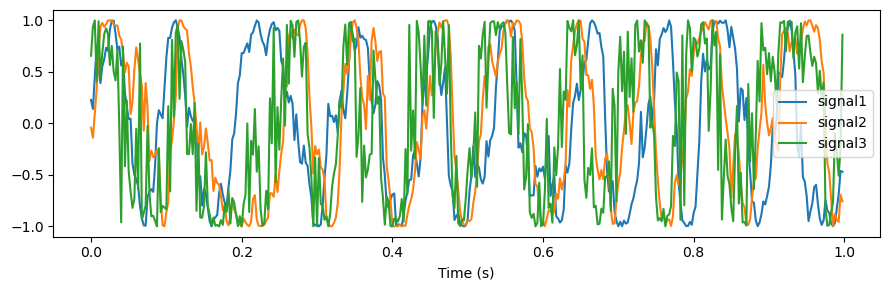

In [16]:
t_max_pl = 2.0; time_step_pl = 0.0025
n_bins_pl = int(np.ceil(t_max_pl / time_step_pl))
time_pl = time_step_pl * np.arange(n_bins_pl)
rng = np.random.default_rng(42)
f0 = 10.0; df_jitter = 1.5; delta_phi0 = 0.5; phi_shift = np.pi / 4
delta_phi1 = 2 * np.pi * f0 * (1 + df_jitter * rng.normal(size=n_bins_pl)) * time_step_pl
delta_phi2 = 2 * np.pi * f0 * (1 + df_jitter * rng.normal(size=n_bins_pl)) * time_step_pl
phi1 = np.cumsum(delta_phi1)
phi2 = np.cumsum(delta_phi2)
phi3 = phi2 + delta_phi0 * rng.normal(size=n_bins_pl) + phi_shift
signal1 = np.sin(phi1)
signal2 = np.sin(phi2)
signal3 = np.sin(phi3)
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl[:400], signal1[:400], label='signal1')
ax.plot(time_pl[:400], signal2[:400], label='signal2')
ax.plot(time_pl[:400], signal3[:400], label='signal3')
ax.set_xlabel('Time (s)'); ax.legend()
plt.tight_layout()

**Example**: Apply `hilbert_bandpassed` to the first signal and plot the instantaneous phase.

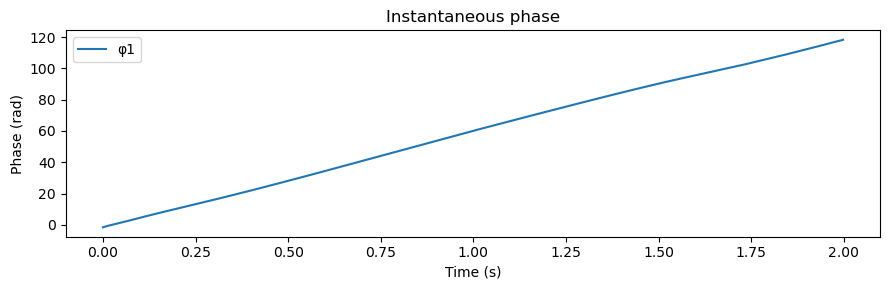

In [17]:
z1, _ = spectral.hilbert_bandpassed(signal1, f0, 0.1 * f0, time_step_pl)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl, np.unwrap(np.angle(z1)), label='φ1')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Phase (rad)')
ax.set_title('Instantaneous phase'); ax.legend()
plt.tight_layout()

**Exercise**: Apply `hilbert_bandpassed` to the second signal and plot its instantaneous phase.

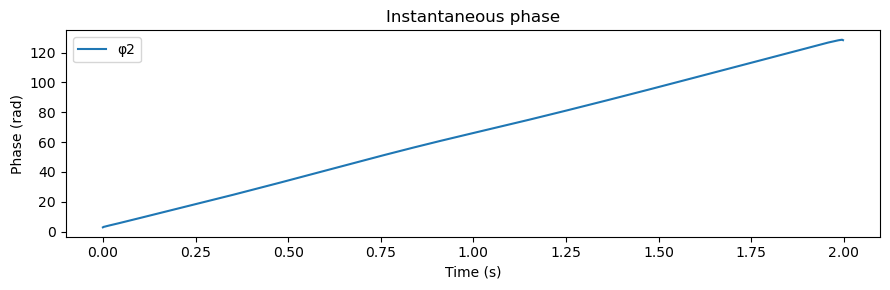

In [27]:
z2, _ = spectral.hilbert_bandpassed(signal2, f0, 0.1 * f0, time_step_pl)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl, np.unwrap(np.angle(z2)), label='φ2')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Phase (rad)')
ax.set_title('Instantaneous phase'); ax.legend()
plt.tight_layout()

**Exercise**: Apply `hilbert_bandpassed` to the third signal and plot the instantaneous phase of all three signals together.

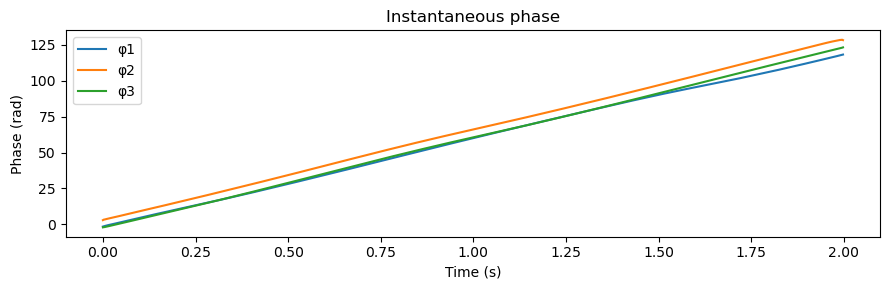

In [28]:
z3, _ = spectral.hilbert_bandpassed(signal3, f0, 0.1 * f0, time_step_pl)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl, np.unwrap(np.angle(z1)), label='φ1')
ax.plot(time_pl, np.unwrap(np.angle(z2)), label='φ2')
ax.plot(time_pl, np.unwrap(np.angle(z3)), label='φ3')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Phase (rad)')
ax.set_title('Instantaneous phase'); ax.legend()
plt.tight_layout()

Run the cell below to compute the Hilbert transform for all three signals.

In [20]:
z1, _ = spectral.hilbert_bandpassed(signal1, f0, 0.1 * f0, time_step_pl)
z2, _ = spectral.hilbert_bandpassed(signal2, f0, 0.1 * f0, time_step_pl)
z3, _ = spectral.hilbert_bandpassed(signal3, f0, 0.1 * f0, time_step_pl)

**Example**: Plot the pairwise phase differences between the first and the second signal — `np.unwrap(np.angle(z1)) - np.unwrap(np.angle(z2))`. 

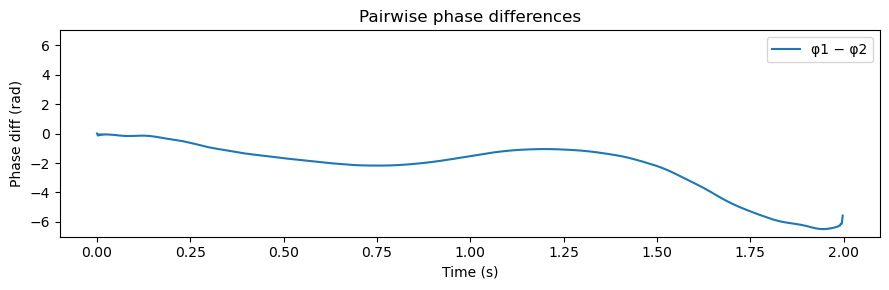

In [43]:
phase_difference = np.unwrap(np.angle(z1)) - np.unwrap(np.angle(z2))
phase_difference -= phase_difference[0]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl, phase_difference, label='φ1 − φ2')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Phase diff (rad)')
ax.set_title('Pairwise phase differences')
ax.set_ylim([-7,7])
ax.legend(); plt.tight_layout()

**Exercise**: Plot the pairwise phase differences between the second and the third signal — `np.unwrap(np.angle(z2)) - np.unwrap(np.angle(z3))`. Does this signal pair have an approximately constant phase difference? If it does, the signals are phase-locked.

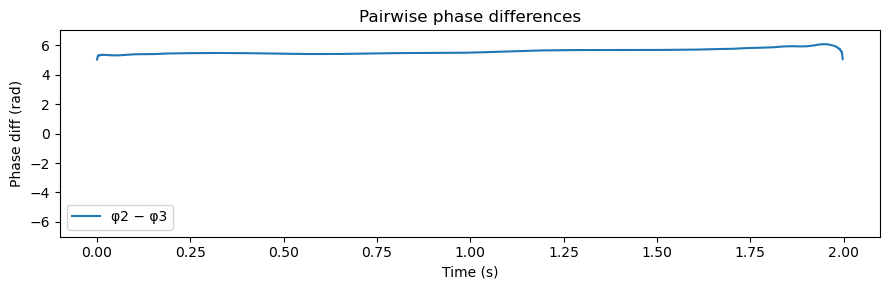

In [44]:
phase_difference = np.unwrap(np.angle(z2)) - np.unwrap(np.angle(z3))
phase_difference -= phase_difference[0]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl, np.unwrap(np.angle(z2)) - np.unwrap(np.angle(z3)), label='φ2 − φ3')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Phase diff (rad)')
ax.set_title('Pairwise phase differences')
ax.set_ylim([-7,7])
ax.legend(); plt.tight_layout()

**Exercise**: Plot the pairwise phase differences between the first and the third signal — `np.unwrap(np.angle(z1)) - np.unwrap(np.angle(z3))`. Does this signal pair have an approximately constant phase difference? If it does, the signals are phase-locked.

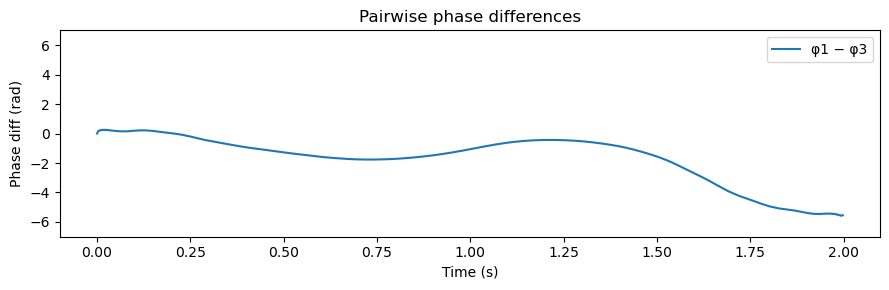

In [45]:
phase_difference = np.unwrap(np.angle(z1)) - np.unwrap(np.angle(z3))
phase_difference -= phase_difference[0]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl,phase_difference, label='φ1 − φ3')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Phase diff (rad)')
ax.set_title('Pairwise phase differences')
ax.set_ylim([-7,7])
ax.legend(); plt.tight_layout()

**Exercise**: Increase the bandpass width to `f_width = 0.5 * f0` and reapply `hilbert_bandpassed` to `signal1`. Run the second cell below to plot the instantaneous amplitude `np.abs(z)` - the envelope - for the first 2 s alongside the original signal. How does a wider bandpass affect the amplitude of the envelope?

In [20]:
z1_wide, s1_filt = spectral.hilbert_bandpassed(signal1, f0, 0.5 * f0, time_step_pl)

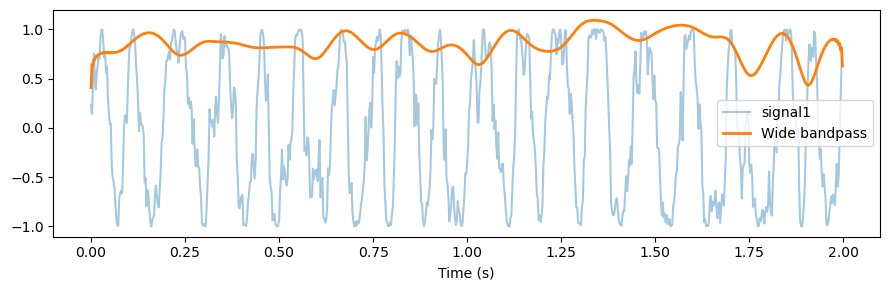

In [21]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl, signal1, alpha=0.4, label='signal1')
ax.plot(time_pl, np.abs(z1_wide), lw=2, label='Wide bandpass')
ax.set_xlabel('Time (s)'); ax.legend(); plt.tight_layout()

**Exercise**: Use a narrower bandpass width (`f_width = 0.1 * f0`) and reapply `hilbert_bandpassed` to `signal1`. Run the second cell below to plot the instantaneous amplitude `np.abs(z)` for the first 2 s alongside the original signal. If you compare the envelope produced from the narrow bandpass in this exercise with the envelope produced with the wide bandpass in the previous exercise, how does bandpass width affect the envelope?

In [46]:
z1_narrow, s1_filt = spectral.hilbert_bandpassed(signal1, f0, 0.1 * f0, time_step_pl)

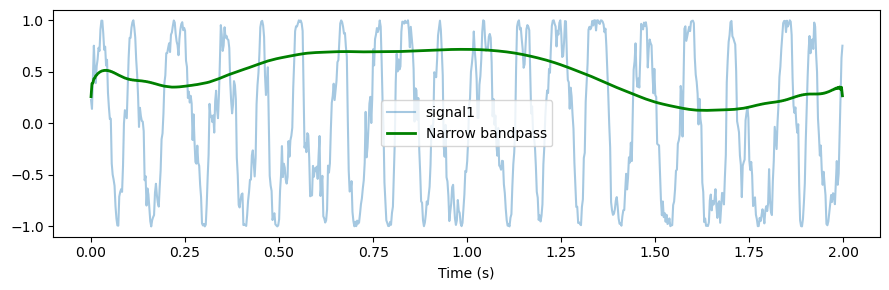

In [47]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl, signal1, alpha=0.4, label='signal1')
ax.plot(time_pl, np.abs(z1_narrow), color = 'green', lw=2, label='Narrow bandpass')
ax.set_xlabel('Time (s)'); ax.legend(); plt.tight_layout()

**Exercise**: Run the cell below to compute the phase difference between a V1 and V4 LFP channel and plot the instantaneous phase difference over time. Does it appear constant (locked) or drifting? Look at the previous wavelet spectrograms. If you see some phase-locking, is it consistent with the stimulus onset at 0.5 seconds? Try with other promising frequencies - change the value of `f_promising`.

Both signals are Hilbert bandpassed at `f_mid=f_promising` with `f_width=5.0` Hz and `dt=time_step_lfp=1e-3`. 

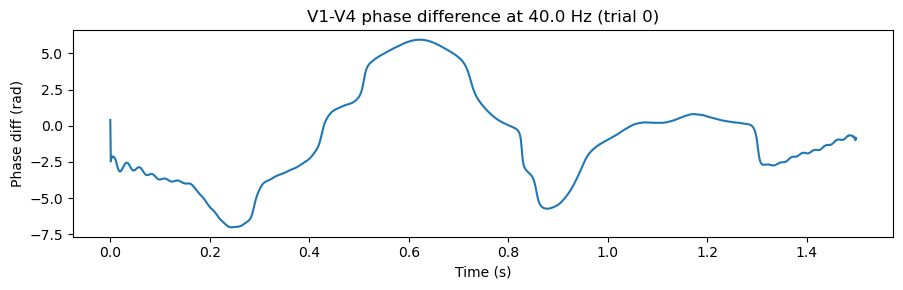

In [48]:
data_real = scipy.io.loadmat('../data/spectral_dataset.mat')
v1_lfp = data_real['V1_lfp']; v4_lfp = data_real['V4_lfp']
channel = 22
f_promising = 40.0 # CHANGE ME
time_step_lfp = 1e-3
itrial = 0
zv1, _ = spectral.hilbert_bandpassed(v1_lfp[itrial, :, channel], f_promising, 5.0, time_step_lfp)
zv4, _ = spectral.hilbert_bandpassed(v4_lfp[itrial, :], f_promising, 5.0, time_step_lfp)
t_lfp0 = time_step_lfp * np.arange(v1_lfp.shape[1])
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_lfp0, np.unwrap(np.angle(zv1)) - np.unwrap(np.angle(zv4)))
ax.set_xlabel('Time (s)'); ax.set_ylabel('Phase diff (rad)')
ax.set_title(f'V1-V4 phase difference at {f_promising} Hz (trial {itrial})')
plt.tight_layout()

## The Phase Locking Value

The phase locking value (PLV) quantifies how consistently two signals maintain a fixed phase relationship. Given two analytic signals $z_a(t)$ and $z_b(t)$, the PLV is:

$$\text{PLV} = \left|\frac{1}{T} \sum_{k=1}^{T} \frac{z_a(t_k)}{|z_a(t_k)|} \cdot \overline{\frac{z_b(t_k)}{|z_b(t_k)|}}\right|$$

Each factor $z/|z|$ is the unit-phasor of the analytic signal — the instantaneous phase direction on the complex unit circle. Their product gives the instantaneous phase difference as a phasor. Averaging over time and taking the absolute value yields a scalar between 0 and 1: $\text{PLV} = 1$ means perfectly constant phase difference; $\text{PLV} = 0$ means a uniformly random phase difference.

The function `spectral.phase_locking_value(z_a, z_b)` computes this value for two 1D arrays of complex analytic signals. When both signals are analytic outputs of `hilbert_bandpassed`, the PLV measures phase locking in the bandpass range.

| Code | Description |
| --- | --- |
| `plv = spectral.phase_locking_value(z_a, z_b)` | Calculate the PLV for two analytic signals `z_a` and `z_b` |
| `np.abs(plv)` | PLV magnitude (0 to 1) |
| `np.angle(plv)` | Mean phase difference (radians) |
| `np.degrees(np.angle(plv))` | Mean phase difference in degrees |

---

Run the cell below to compute the Hilbert transform for all three signals.

In [50]:
z1, _ = spectral.hilbert_bandpassed(signal1, f0, 0.1 * f0, time_step_pl)
z2, _ = spectral.hilbert_bandpassed(signal2, f0, 0.1 * f0, time_step_pl)
z3, _ = spectral.hilbert_bandpassed(signal3, f0, 0.1 * f0, time_step_pl)

**Example**: Compute the PLV between the Hilbert transform of signal 1 and signal 2 and print the result.

In [51]:
plv12 = spectral.phase_locking_value(z1, z2)
print(f'|PLV(1,2)| = {np.abs(plv12):.3f}')

|PLV(1,2)| = 0.561


**Exercise**: Compute the PLV between the Hilbert transform of signals 1 and 3 and print the result. Is the PLV higher, lower, or roughly the same as the PLV between signals 1 and 2 in the example above?

In [52]:
plv13 = spectral.phase_locking_value(z1, z3)
print(f'|PLV(1,3)| = {np.abs(plv13):.3f}')

|PLV(1,3)| = 0.527


**Exercise**: Compute the PLV between the Hilbert transform of signals 3 and 2 and print the result. Which of the three pairwise combinations of signals has the highest PLV? **Hint**: It should be the same pair you identified to have a constant phase difference from the plots in the previous section.

In [54]:
plv32 = spectral.phase_locking_value(z3, z2)
print(f'|PLV(3,2)| = {np.abs(plv32):.3f}')


|PLV(3,2)| = 0.984


**Exercise**: Calculate the phase difference between signals 3 and 2 from the PLV and verify that it's close to `phi_shift` (defined in the signal generation code). Convert both to degrees for readability.

**Hint**: Useful functions - `np.degrees` and `np.angle(plv)`.

In [55]:
print(f'Measured mean phase diff (3,2): {np.degrees(np.angle(plv32)):.2f}°')
print(f'Expected phi_shift:             {np.degrees(phi_shift):.2f}°')

Measured mean phase diff (3,2): 40.96°
Expected phi_shift:             45.00°


Run the cell below to regenerate signal 3, but this time with the phase noise of `signal3` increased to `delta_phi0 = 2.0` (instead of 0.5).

In [56]:
rng = np.random.default_rng(0)
phi3 = phi2 + 2.0 * rng.normal(size=n_bins_pl) + phi_shift
s3 = np.sin(phi3)
z3, _ = spectral.hilbert_bandpassed(s3, f0, 0.1 * f0, time_step_pl)

**Exercise**:  Recompute the PLVs. How does more phase noise change `|PLV(2,3)|`?

In [57]:
print(f'|PLV(2,3)| (high noise): {np.abs(spectral.phase_locking_value(z2, z3)):.3f}')

|PLV(2,3)| (high noise): 0.790


**Example**: Compute the PLV between the hilbert bandpassed `signal1` and `signal3` at different frequencies and plot the PLV between the two signals as a function of frequency. At what frequency is the PLV the highest? How does the result change if you compare `signal2` and `signal3`?

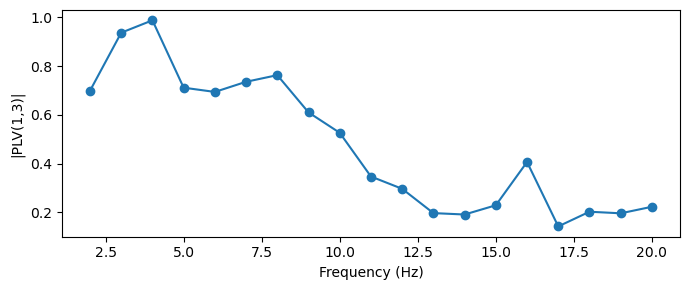

In [59]:
freqs_test = np.arange(2, 21, 1.0)
plvs_ab = []
for ft in freqs_test:
    za_t, _ = spectral.hilbert_bandpassed(signal1, ft, 0.1 * ft, time_step_pl)
    zb_t, _ = spectral.hilbert_bandpassed(signal3, ft, 0.1 * ft, time_step_pl)
    plvs_ab.append(np.abs(spectral.phase_locking_value(za_t, zb_t)))
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(freqs_test, plvs_ab, 'o-')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('|PLV(1,3)|')
plt.tight_layout()

**Exercise**: Compute the PLV between the hilbert bandpassed `signal2` and `signal3` at different frequencies and plot the PLV between the two signals as a function of frequency. At what frequency is the PLV the highest? How does the result change if you compare `signal2` and `signal3`?

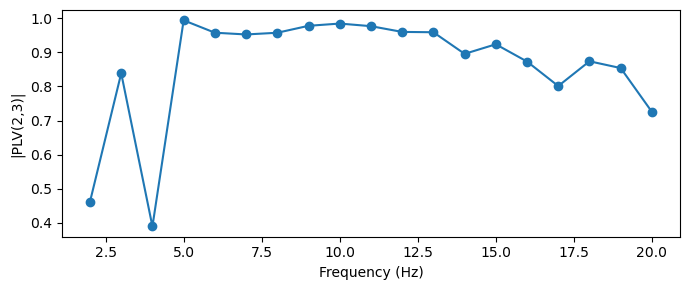

In [60]:
freqs_test = np.arange(2, 21, 1.0)
plvs_ab = []
for ft in freqs_test:
    za_t, _ = spectral.hilbert_bandpassed(signal2, ft, 0.1 * ft, time_step_pl)
    zb_t, _ = spectral.hilbert_bandpassed(signal3, ft, 0.1 * ft, time_step_pl)
    plvs_ab.append(np.abs(spectral.phase_locking_value(za_t, zb_t)))
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(freqs_test, plvs_ab, 'o-')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('|PLV(2,3)|')
plt.tight_layout()

## PLV Convergence and LFP Phase Analysis

A single PLV estimate from a finite-length recording is noisy: even for two completely independent signals, the empirical PLV from $T$ samples is on average $1/\sqrt{T}$ due to the circular statistics of phase differences. To assess how much data is needed to reliably detect a given level of phase locking, it is informative to plot the PLV estimated from progressively longer stretches of data. If the signals are truly phase-locked, then running PLV converges to a stable value; if they are independent, it decreases toward zero as $1/\sqrt{T}$.

For real LFP recordings, the PLV measured between two brain areas is not expected to be constant over time: phase locking may be stronger during particular behavioral epochs (such as the delay period between a cue and a motor response) and weaker during others. A time-resolved PLV can be computed by applying the PLV formula over a sliding window rather than the full trial.

The PLV is a scalar that integrates phase information over both time and trials. The function `np.angle(plv)` gives the mean phase difference, which has a direct neurophysiological interpretation: a non-zero mean offset between two areas at a specific frequency can indicate the presence of a traveling wave or an axonal conduction delay.

| Code | Description |
| --- | --- |
| `plv_t[i] = np.abs(spectral.phase_locking_value(z1[:i+1], z2[:i+1]))` | Calculating PLV from the first `i+1` samples |
| `1.0 / np.sqrt(np.arange(1, n_bins_pl + 1))` | $1/\sqrt{T}$ chance level for an independent pair |
| `z, _ = spectral.hilbert_bandpassed(signal, f_mid, f_width, dt)` | Analytic signal of a bandpassed real signal |

---

Run the cell below to generate three 10 Hz signals. Each has an independently jittered phase process — but two of the three share a hidden phase relationship.

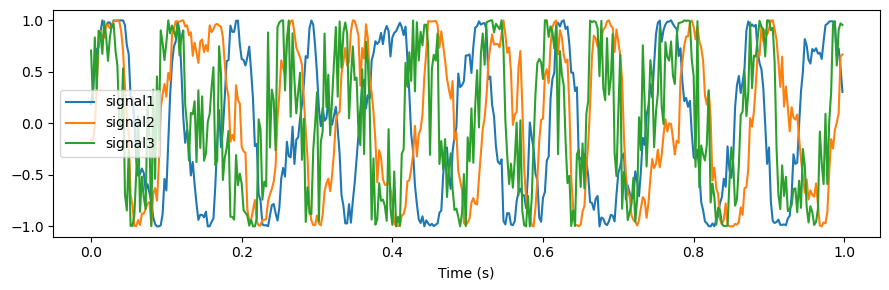

In [61]:
t_max_pl = 15.0; time_step_pl = 0.0025
n_bins_pl = int(np.ceil(t_max_pl / time_step_pl))
time_pl = time_step_pl * np.arange(n_bins_pl)
rng = np.random.default_rng(0)
f0 = 10.0; df_jitter = 1.5; delta_phi0 = 0.5; phi_shift = np.pi / 4
delta_phi1 = 2 * np.pi * f0 * (1 + df_jitter * rng.normal(size=n_bins_pl)) * time_step_pl
delta_phi2 = 2 * np.pi * f0 * (1 + df_jitter * rng.normal(size=n_bins_pl)) * time_step_pl
phi1 = np.cumsum(delta_phi1)
phi2 = np.cumsum(delta_phi2)
phi3 = phi2 + delta_phi0 * rng.normal(size=n_bins_pl) + phi_shift
signal1 = np.sin(phi1)
signal2 = np.sin(phi2)
signal3 = np.sin(phi3)
z1, _ = spectral.hilbert_bandpassed(signal1, f0, 0.1 * f0, time_step_pl)
z2, _ = spectral.hilbert_bandpassed(signal2, f0, 0.1 * f0, time_step_pl)
z3, _ = spectral.hilbert_bandpassed(signal3, f0, 0.1 * f0, time_step_pl)

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl[:400], signal1[:400], label='signal1')
ax.plot(time_pl[:400], signal2[:400], label='signal2')
ax.plot(time_pl[:400], signal3[:400], label='signal3')
ax.set_xlabel('Time (s)'); ax.legend()
plt.tight_layout()

**Example**: Compute and plot the running PLV between `signal2` and `signal3` as a function of time. Show the $1/\sqrt{T}$ chance level for comparison.

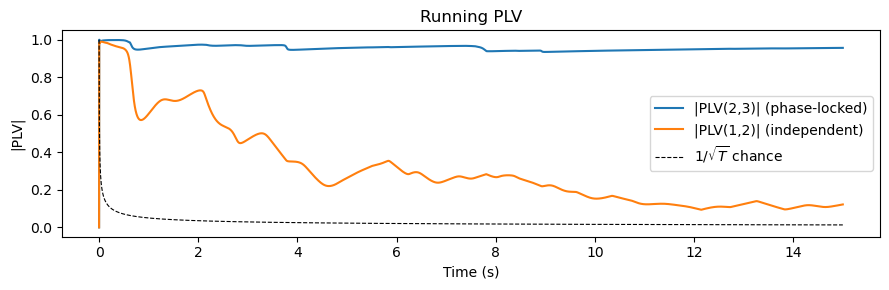

In [62]:
plv_t_23 = np.zeros(n_bins_pl)
plv_t_12 = np.zeros(n_bins_pl)
for i in range(1, n_bins_pl):
    plv_t_23[i] = np.abs(spectral.phase_locking_value(z2[:i + 1], z3[:i + 1]))
    plv_t_12[i] = np.abs(spectral.phase_locking_value(z1[:i + 1], z2[:i + 1]))
chance = 1.0 / np.sqrt(np.arange(1, n_bins_pl + 1))
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(time_pl, plv_t_23, label='|PLV(2,3)| (phase-locked)')
ax.plot(time_pl, plv_t_12, label='|PLV(1,2)| (independent)')
ax.plot(time_pl, chance, 'k--', lw=0.8, label=r'$1/\sqrt{T}$ chance')
ax.set_xlabel('Time (s)'); ax.set_ylabel('|PLV|')
ax.set_title('Running PLV'); ax.legend()
plt.tight_layout()

**Exercise**: Based on the running PLV plot, roughly how many seconds of data are needed before `|PLV(2,3)|` clearly separates from the chance level? In addition to the visual inspection print the PLV value at `t = 0.5 s`, `t = 2.0 s`, and `t = 10.0 s` for both pairs.

In [63]:
for t_q in [0.5, 2.0, 10.0]:
    idx = int(t_q / time_step_pl) - 1
    print(f't={t_q}s  |PLV(2,3)|={plv_t_23[idx]:.3f}  |PLV(1,2)|={plv_t_12[idx]:.3f}')

t=0.5s  |PLV(2,3)|=0.997  |PLV(1,2)|=0.953
t=2.0s  |PLV(2,3)|=0.973  |PLV(1,2)|=0.728
t=10.0s  |PLV(2,3)|=0.941  |PLV(1,2)|=0.153


Run the cell below to load the artificial LFP dataset.

In [64]:
data_real = scipy.io.loadmat('../data/spectral_dataset.mat')
v1_lfp = data_real['V1_lfp']; v4_lfp = data_real['V4_lfp']
time_step_lfp = 1e-3

**Exercise**: For the first trial, compute the PLV between V1 channel 22 and V4 at a range of frequencies from 5 to 120 Hz (step 5 Hz, bandwidth 20% of center frequency). Plot `|PLV|` vs frequency. At which frequency is V1-V4 coupling strongest?

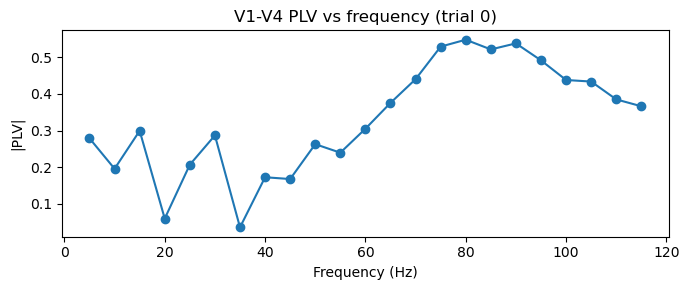

In [ ]:
ichan = 22
freqs_lfp = np.arange(5, 120, 5.0)
plv_freq = []
v1_cell = v1_lfp[0, :, ichan].astype(float)
v4_cell = v4_lfp[0, :].astype(float)
for ft in freqs_lfp:
    za, _ = spectral.hilbert_bandpassed(v1_cell, ft, 0.2 * ft, time_step_lfp)
    zb, _ = spectral.hilbert_bandpassed(v4_cell, ft, 0.2 * ft, time_step_lfp)
    plv_freq.append(np.abs(spectral.phase_locking_value(za, zb)))
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(freqs_lfp, plv_freq, 'o-')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('|PLV|')
ax.set_title('V1-V4 PLV vs frequency (trial 0)')
plt.tight_layout()

**Exercise**: Compute the PLV between V1 channel 22 and V4 at 40 Hz for each of the recorded trials separately. Plot the distribution of single-trial PLV magnitudes as a histogram. Use `time_step_lfp=1e-3` and `f_width=5.0`.

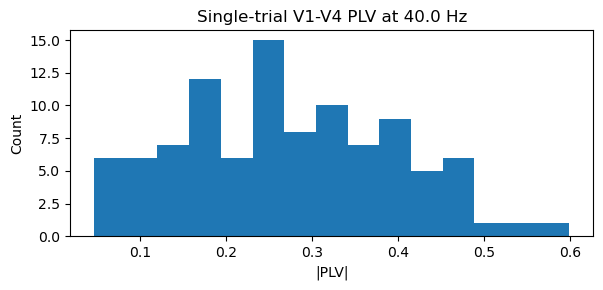

In [ ]:
ichan = 22
f_promising = 40.0

plvs_trials = []
for itrial in range(v1_lfp.shape[0]):
    zv1_t, _ = spectral.hilbert_bandpassed(
        v1_lfp[itrial, :, ichan].astype(float), f_promising, 5.0, time_step_lfp)
    zv4_t, _ = spectral.hilbert_bandpassed(
        v4_lfp[itrial, :].astype(float), f_promising, 5.0, time_step_lfp)
    plvs_trials.append(np.abs(spectral.phase_locking_value(zv1_t, zv4_t)))
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(plvs_trials, bins=15)
ax.set_xlabel('|PLV|'); ax.set_ylabel('Count')
ax.set_title(f'Single-trial V1-V4 PLV at {f_promising} Hz')
plt.tight_layout()